In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_contradiction.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_mnli_m_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_

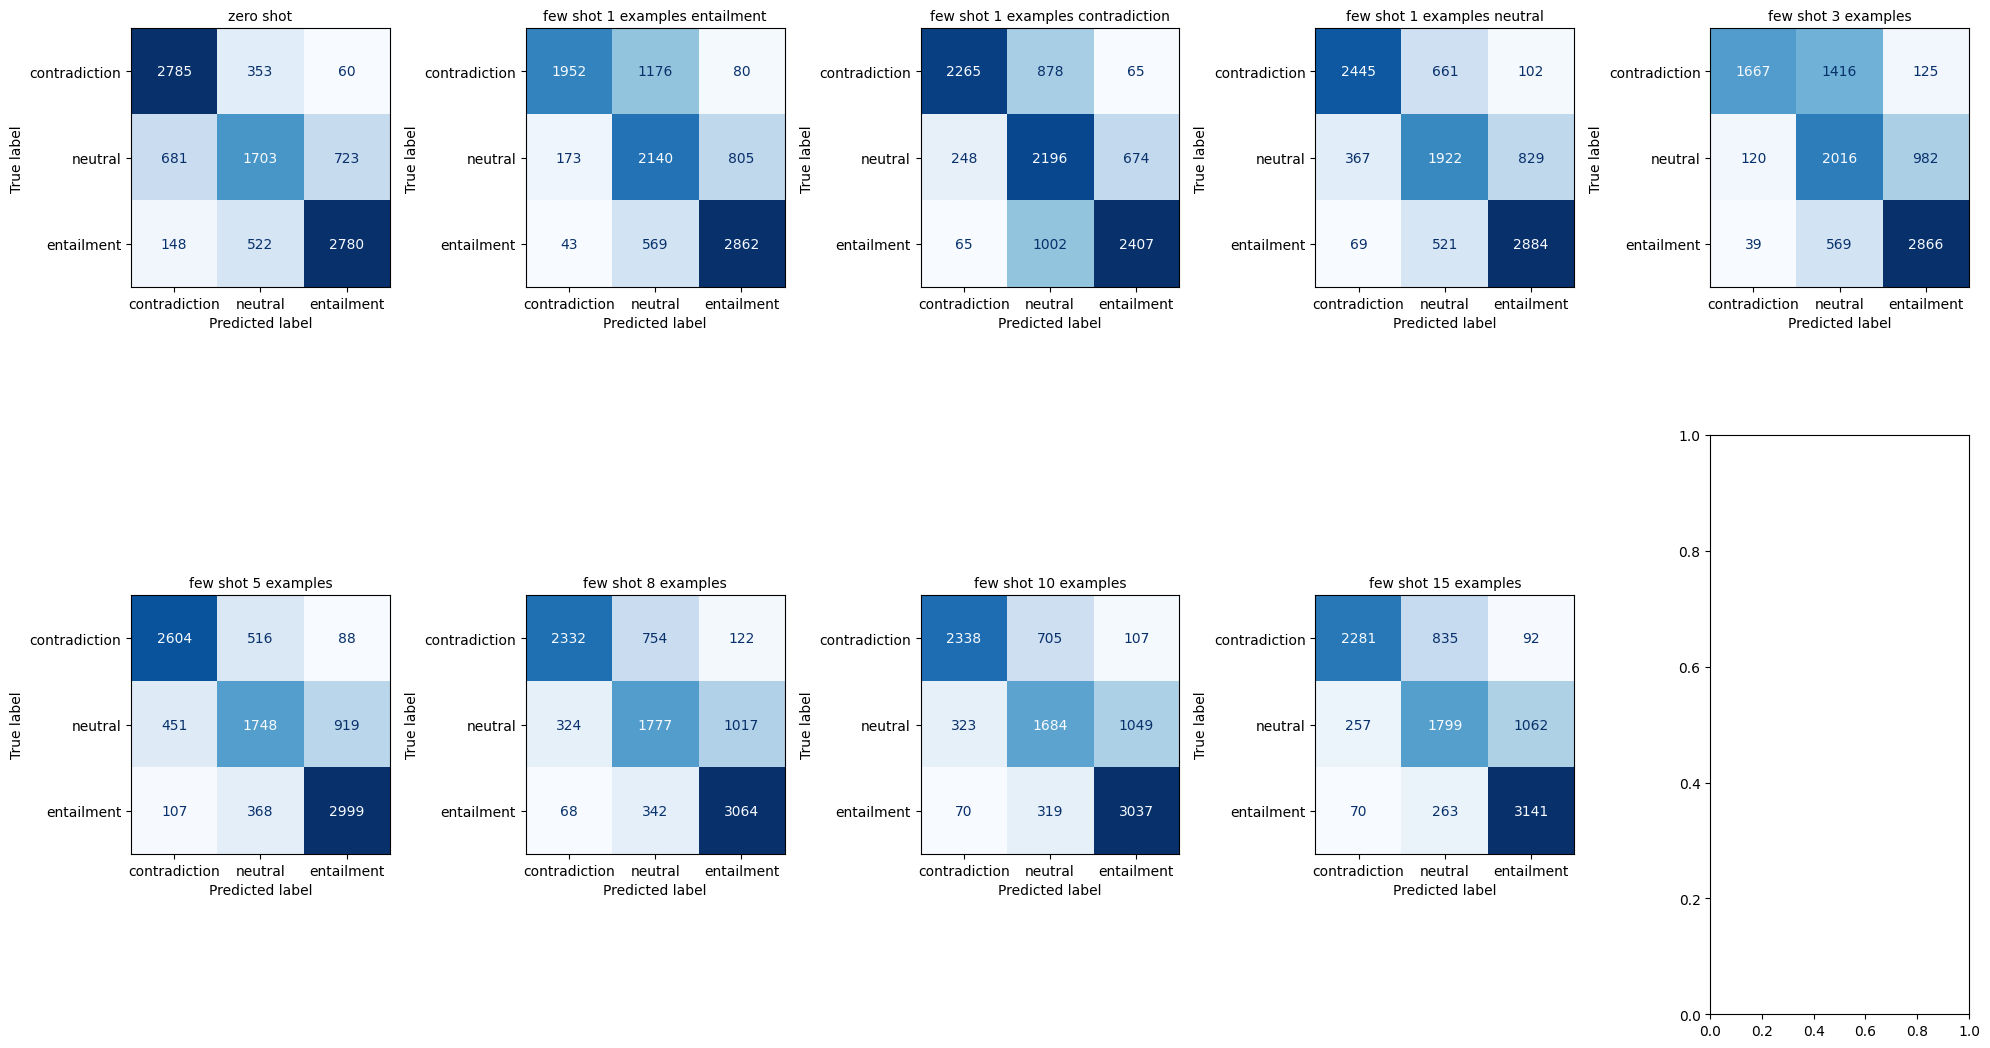

In [11]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 examples entailment',
    'few shot 1 examples contradiction',
    'few shot 1 examples neutral',
    'few shot 3 examples',
    'few shot 5 examples',
    'few shot 8 examples',
    'few shot 10 examples',
    'few shot 15 examples'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'mnli_m',
                'quantization': '4bit',
                'training_mode': mode,
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (contradiction)",
    '1 mm example (neutral)',
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.7451,0.7371,0.7416,0.7365,0.6190,0.6167
1 example (entailment),0.7096,0.7383,0.7062,0.7100,0.5717,0.5639
1 example (contradiction),0.7008,0.7275,0.7011,0.7069,0.5582,0.5520
1 mm example (neutral),0.7399,0.7413,0.7362,0.7374,0.6099,0.6089
3 examples,0.6683,0.7127,0.6637,0.6661,0.5134,0.5014
5 examples,0.7501,0.7454,0.7452,0.7425,0.6262,0.6237
8 examples,0.7319,0.7345,0.7263,0.7259,0.6000,0.5961
10 examples,0.7329,0.7341,0.7266,0.7255,0.6016,0.5972
15 examples,0.7368,0.7423,0.7307,0.7304,0.6086,0.6034


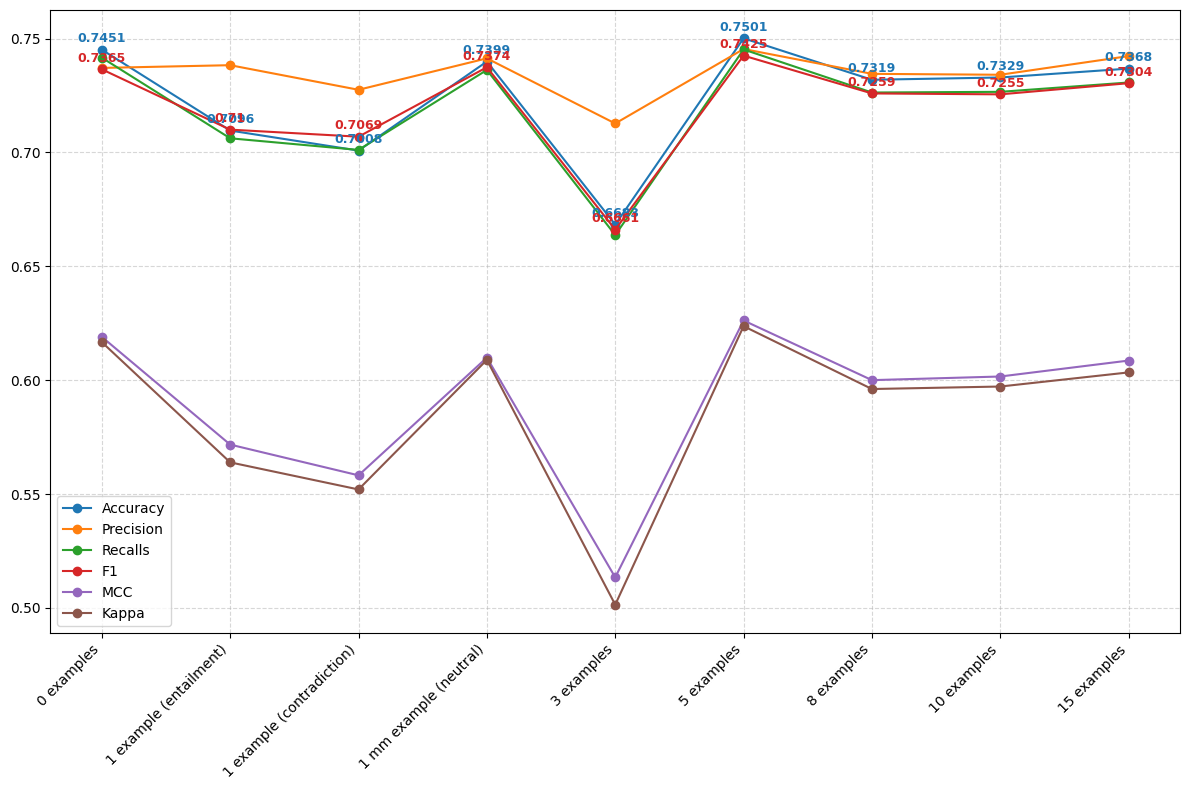

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_m_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_m_examples_contradiction.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_mnli_mm_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_m_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Mistral_7B_Instruct_v0_3/Results/c

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


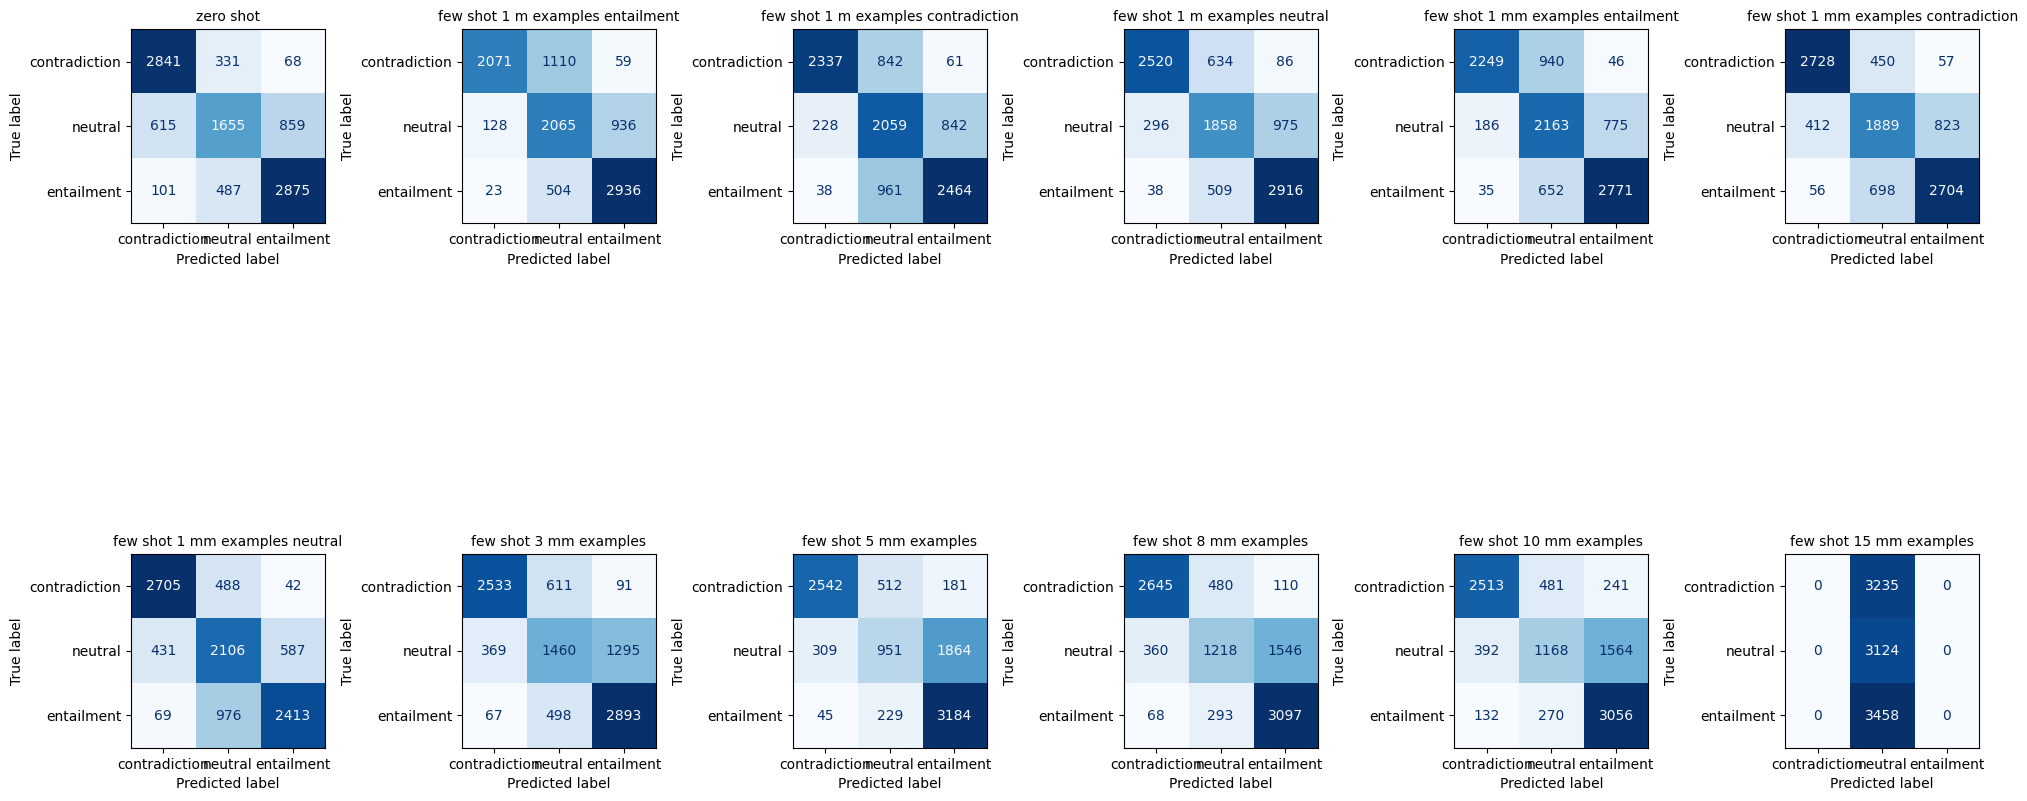

In [14]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 m examples entailment',
    'few shot 1 m examples contradiction',
    'few shot 1 m examples neutral',
    'few shot 1 mm examples entailment',
    'few shot 1 mm examples contradiction',
    'few shot 1 mm examples neutral',
    'few shot 3 mm examples',
    'few shot 5 mm examples',
    'few shot 8 mm examples',
    'few shot 10 mm examples',
    'few shot 15 mm examples'    
]

fig, axes = plt.subplots(2, 6, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'mnli_mm',
                'quantization': '4bit',
                'training_mode': mode,
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
labels = [
    "0 examples",
    "1 m example (entailment)",
    "1 m example (contradiction)",
    '1 m example (neutral)',
    "1 mm example (entailment)",
    "1 mm example (contradiction)",
    '1 mm example (neutral)',
    "3 mm examples",
    "5 mm examples",
    "8 mm examples",
    "10 mm examples",
    "15 mm examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.7497,0.7414,0.7453,0.7394,0.6265,0.6233
1 m example (entailment),0.7193,0.7467,0.7157,0.7197,0.5854,0.5783
1 m example (contradiction),0.6977,0.7209,0.6970,0.7035,0.5510,0.5469
1 m example (neutral),0.7419,0.7451,0.7379,0.7390,0.6137,0.6117
1 mm example (entailment),0.7317,0.7527,0.7296,0.7345,0.6021,0.5974
1 mm example (contradiction),0.7457,0.7433,0.7433,0.7432,0.6182,0.6181
1 mm example (neutral),0.7359,0.7424,0.7360,0.7372,0.6061,0.6043
3 mm examples,0.7014,0.6992,0.6957,0.6924,0.5546,0.5500
5 mm examples,0.6801,0.6829,0.6703,0.6524,0.5388,0.5156
8 mm examples,0.7090,0.7080,0.7010,0.6897,0.5739,0.5602


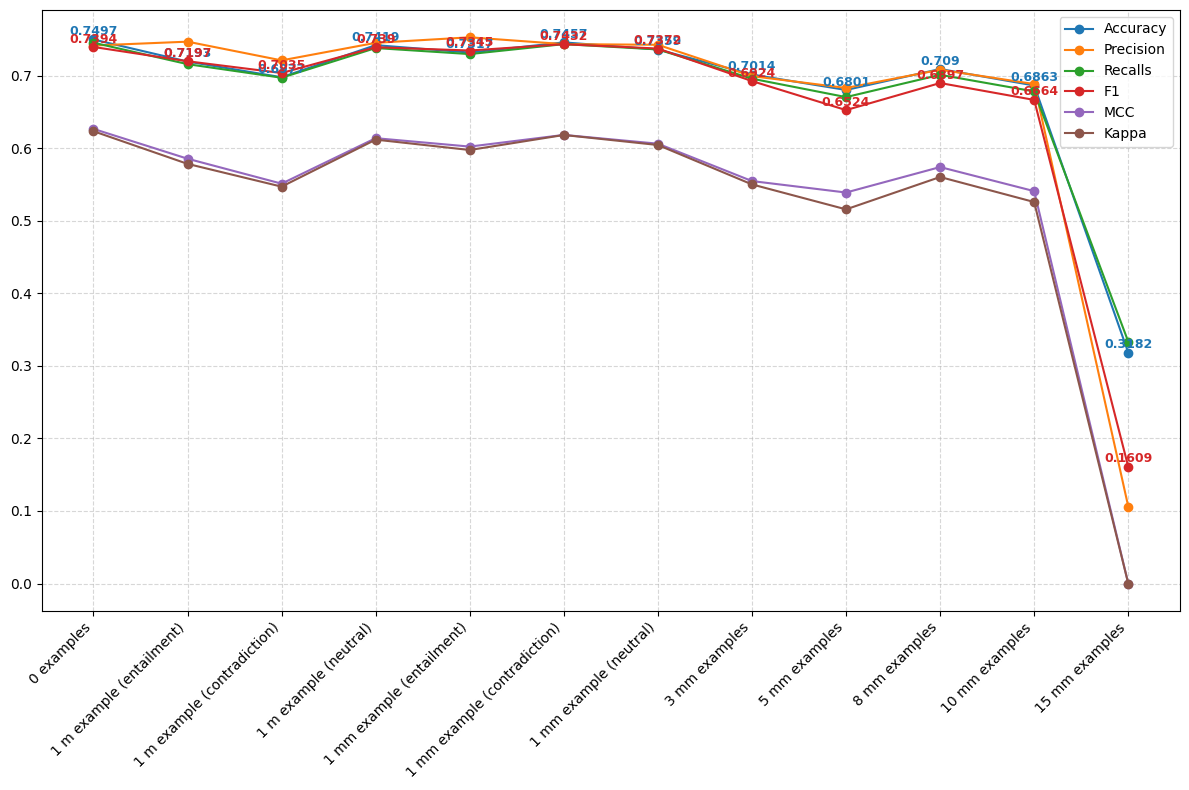

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()